<a href="https://colab.research.google.com/github/merciesofGod/behavioral-fraud-detection/blob/main/Behavioral_Fraud_Detection_and_Risk_Analysis_Using_Transaction_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# Behavioral Fraud Detection and Risk Analysis
# IBM AML Stateful Behavioral Fraud Dataset
#
# Author: Mercy Sunday
# =================================================

#Business Problem

Financial institutions process millions of transactions every day. Traditional fraud detection systems often focus on the details of a single transaction, which can miss fraudulent activities that only become apparent when looking at a customer's behaviour over time.

The organization needs a data-driven approach that analyzes behavioural patterns to identify potentially fraudulent transactions early, reduce financial losses, and support more effective fraud monitoring.

#Business Objectives

This project aims to:

Understand transaction behaviour across customer accounts.
Identify patterns associated with fraudulent transactions.
Analyze behavioural features that contribute to fraud risk.
Build a predictive model capable of distinguishing fraudulent transactions from legitimate ones.
Generate recommendations that support fraud prevention and risk management.

#Business Questions

Instead of jumping into code, we'll answer questions like:

-What percentage of transactions are fraudulent?

-Which transaction characteristics are most common in fraudulent activities?

-Which behavioural features are strongest indicators of fraud?

-Are there transaction amount thresholds associated with increased fraud?

-Do fraud patterns differ across customer behaviour?

-Which features contribute most to model predictions?

These are the kinds of questions a bank or fintech company would actually care about.

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
!pip install -q kaggle


In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_2e87855e4502013abb894cdacd71e84e"

In [ ]:
!kaggle datasets list -s fraud

ref                                                          title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
mlg-ulb/creditcardfraud                                      Credit Card Fraud Detection                         69155672  2018-03-23 01:17:27.913000        1178968      13405  0.85294116       
whenamancodes/fraud-detection                                Fraud Detection                                     69155672  2022-09-12 11:54:40.550000          13794        143  1                
dhanushnarayananr/credit-card-fraud                          Credit Card Fraud                                   30281243  2022-05-07 15:09:29.617000          32728        244  0.9411765        
ealaxi/paysim1           

In [ ]:
!kaggle datasets download -d vai136/ibm-aml-stateful-behavioral-fraud-dataset

Dataset URL: https://www.kaggle.com/datasets/vai136/ibm-aml-stateful-behavioral-fraud-dataset
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 514M/514M [00:04<00:00, 115MB/s]



In [ ]:
!unzip ibm-aml-stateful-behavioral-fraud-dataset.zip -d fraud_data

Archive:  ibm-aml-stateful-behavioral-fraud-dataset.zip
  inflating: fraud_data/LICENSE      
  inflating: fraud_data/README.md    
  inflating: fraud_data/Sample_graphs/Benchmark vs Chronological.png  
  inflating: fraud_data/Sample_graphs/Feature Correlation Heatmap.png  
  inflating: fraud_data/Sample_graphs/amount_distribution.png  
  inflating: fraud_data/Sample_graphs/fraud_distribution.png  
  inflating: fraud_data/Sample_graphs/fraud_rate_by_hour.png  
  inflating: fraud_data/Sample_graphs/payment_channel_fraud_rate.png  
  inflating: fraud_data/Sample_graphs/velocity_score_distribution.png  
  inflating: fraud_data/benchmark/test.parquet  
  inflating: fraud_data/benchmark/train.parquet  
  inflating: fraud_data/benchmark/valid.parquet  
  inflating: fraud_data/chronological/test.parquet  
  inflating: fraud_data/chronological/train.parquet  
  inflating: fraud_data/chronological/valid.parquet  
  inflating: fraud_data/column_dictionary.csv  
  inflating: fraud_data/dataset_st

In [ ]:
import os

os.listdir("fraud_data")

['chronological',
 'documentation',
 'column_dictionary.csv',
 'dataset_statistics.json',
 'benchmark',
 'feature_description.csv',
 'LICENSE',
 'README.md',
 'Sample_graphs',
 'training_dataset_hi_li_small.parquet',
 'metadata']

In [ ]:
os.listdir("fraud_data/chronological")

['train.parquet', 'test.parquet', 'valid.parquet']

In [ ]:
import pandas as pd

train = pd.read_parquet(
    "fraud_data/chronological/train.parquet"
)

In [ ]:
train.shape

(8401675, 16)

In [ ]:
train.head()

,amount,payment_channel,time_since_last_transaction,velocity_score,spending_deviation_score,is_first_transaction,hour,day_of_week,month,is_weekend,is_fraud,is_cross_bank_transfer,is_cross_currency_transfer,is_new_receiver,is_new_bank,is_new_payment_format
0,83.02,Credit Card,60.0,64046,-0.039599,0,0,0,9,0,0,1,0,0,1,0
1,335.36,Credit Card,0.0,64047,-0.039578,0,0,0,9,0,0,1,0,0,1,0
2,1950.74,Cheque,0.0,64048,-0.039445,0,0,0,9,0,0,1,0,0,1,0
3,25.31,Cash,0.0,64049,-0.039603,0,0,0,9,0,0,1,0,0,1,0
4,359.54,Credit Card,0.0,64050,-0.039575,0,0,0,9,0,0,1,0,0,1,0


In [ ]:
train.columns

Index(['amount', 'payment_channel', 'time_since_last_transaction',
       'velocity_score', 'spending_deviation_score', 'is_first_transaction',
       'hour', 'day_of_week', 'month', 'is_weekend', 'is_fraud',
       'is_cross_bank_transfer', 'is_cross_currency_transfer',
       'is_new_receiver', 'is_new_bank', 'is_new_payment_format'],
      dtype='object')

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
amount,8401675.0,4.101433e+06,6.385617e+08,1.000000e-06,164.960000,1363.53000,12267.54,9.659333e+11
time_since_last_transaction,8401675.0,3.105083e+04,9.308584e+04,0.000000e+00,60.000000,660.00000,22740.00,1.170120e+06
velocity_score,8401675.0,4.517174e+03,2.182966e+04,0.000000e+00,3.000000,15.00000,39.00,2.187650e+05
spending_deviation_score,8401675.0,2.383755e+02,5.323805e+05,-7.165514e+08,-0.405008,-0.17155,0.00,1.318965e+09
is_first_transaction,8401675.0,1.198260e-01,3.247580e-01,0.000000e+00,0.000000,0.00000,0.00,1.000000e+00
hour,8401675.0,6.617401e+00,5.015439e+00,0.000000e+00,2.000000,6.00000,11.00,1.600000e+01
day_of_week,8401675.0,2.980140e+00,1.512903e+00,0.000000e+00,2.000000,3.00000,4.00,6.000000e+00
month,8401675.0,9.000000e+00,0.000000e+00,9.000000e+00,9.000000,9.00000,9.00,9.000000e+00
is_weekend,8401675.0,1.208413e-01,3.259427e-01,0.000000e+00,0.000000,0.00000,0.00,1.000000e+00
is_fraud,8401675.0,7.203326e-04,2.682935e-02,0.000000e+00,0.000000,0.00000,0.00,1.000000e+00


In [ ]:
dictionary = pd.read_csv("fraud_data/column_dictionary.csv")
dictionary.head(20)

,Column,Data Type,Category,Description,Nullable
0,amount,float,Transaction,Transaction amount.,No
1,payment_channel,category,Transaction,Payment channel used for the transaction.,No
2,time_since_last_transaction,float,Behavioral,Elapsed time (seconds) since the sender's prev...,No
3,velocity_score,integer,Behavioral,Lifetime number of transactions executed by th...,No
4,spending_deviation_score,float,Behavioral,Online z-score measuring deviation from the se...,No
5,is_first_transaction,boolean,Behavioral,Whether this is the sender's first observed tr...,No
6,hour,integer,Temporal,Hour of day (0–23).,No
7,day_of_week,integer,Temporal,"Day of week (0=Monday, 6=Sunday).",No
8,month,integer,Temporal,Month extracted from transaction timestamp.,No
9,is_weekend,boolean,Temporal,Whether the transaction occurred on a weekend.,No


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8401675 entries, 0 to 8401674
Data columns (total 16 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   amount                       float64
 1   payment_channel              object 
 2   time_since_last_transaction  float64
 3   velocity_score               int64  
 4   spending_deviation_score     float64
 5   is_first_transaction         int64  
 6   hour                         int64  
 7   day_of_week                  int64  
 8   month                        int64  
 9   is_weekend                   int64  
 10  is_fraud                     int64  
 11  is_cross_bank_transfer       int64  
 12  is_cross_currency_transfer   int64  
 13  is_new_receiver              int64  
 14  is_new_bank                  int64  
 15  is_new_payment_format        int64  
dtypes: float64(3), int64(12), object(1)
memory usage: 1.0+ GB


## Target Variable Analysis

The target variable (`is_fraud`) represents whether a transaction is legitimate or fraudulent. Before building any predictive model, it is important to understand the distribution of the target variable. Fraud detection datasets are often highly imbalanced, with fraudulent transactions representing only a small proportion of all transactions. Examining this distribution helps identify potential challenges that may affect model training and evaluation.

In [ ]:
fraud_counts = train["is_fraud"].value_counts()

fraud_counts

,count
is_fraud,
0,8395623
1,6052


In [ ]:
fraud_percentage = (
    train["is_fraud"]
    .value_counts(normalize=True)
    * 100
)

fraud_percentage

,proportion
is_fraud,
0,99.927967
1,0.072033


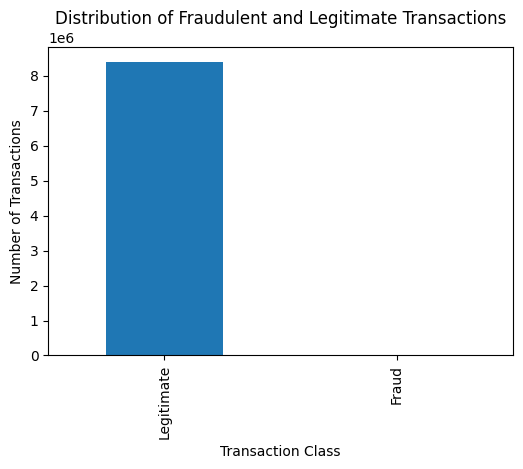

In [ ]:
import matplotlib.pyplot as plt

fraud_counts = train["is_fraud"].value_counts()

plt.figure(figsize=(6,4))

fraud_counts.plot(
    kind="bar"
)

plt.title("Distribution of Fraudulent and Legitimate Transactions")

plt.xlabel("Transaction Class")

plt.ylabel("Number of Transactions")

plt.xticks(
    [0,1],
    ["Legitimate","Fraud"]
)

plt.show()

# Exploratory Data Analysis (EDA)

With a clear understanding of the dataset structure and the distribution of fraudulent transactions, the next step is to explore the characteristics of the data.

The objective of this analysis is to identify patterns, behaviours, and relationships that distinguish fraudulent transactions from legitimate ones. Rather than immediately building a machine learning model, this stage focuses on understanding the business problem through data exploration.

Each analysis in this section is guided by a business question, ensuring that the insights generated can support both fraud detection and decision-making.

# Transaction Amount Analysis
##First Business Question
Do fraudulent transactions involve higher transaction amounts?

Transaction amount is one of the most fundamental variables in fraud detection.

Large transactions may indicate attempts to move significant amounts of money illegally, while unusually small transactions may also be suspicious if fraudsters are testing stolen accounts before making larger withdrawals.

This analysis compares the distribution of transaction amounts between legitimate and fraudulent transactions to determine whether transaction value alone provides useful signals for detecting fraud.

In [ ]:
# Compare summary statistics for transaction amounts
train.groupby("is_fraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,8395623.0,4.082136e+06,6.376640e+08,0.000001,164.7600,1361.16,12258.540,9.659333e+11
1,6052.0,3.087139e+07,1.413029e+09,0.003227,2077.6625,6646.40,16722.365,8.485314e+10


In [ ]:
sample = train.sample(n=100000, random_state=42)

<Axes: title={'center': 'amount'}, xlabel='is_fraud'>

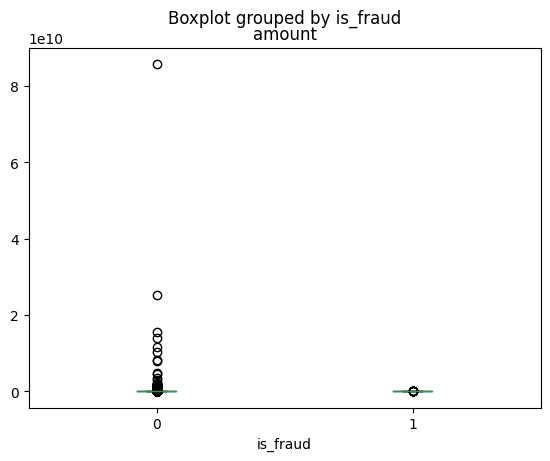

In [ ]:
sample.boxplot(
    column="amount",
    by="is_fraud",
    grid=False
)

<Figure size 1000x600 with 0 Axes>

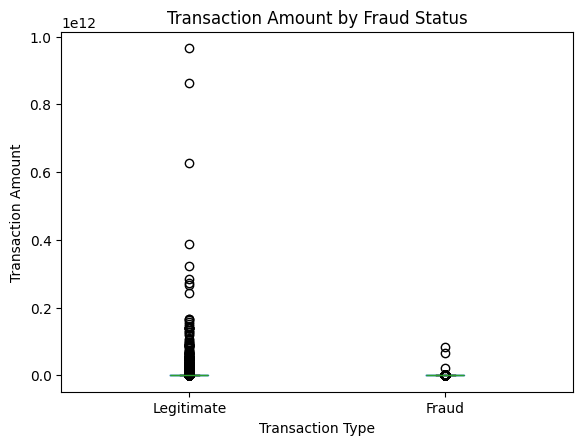

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

train.boxplot(
    column="amount",
    by="is_fraud",
    grid=False
)

plt.title("Transaction Amount by Fraud Status")
plt.suptitle("")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")

plt.xticks(
    [1,2],
    ["Legitimate","Fraud"]
)

plt.show()

### Interpretation

The summary statistics indicate that fraudulent transactions generally involve higher transaction amounts than legitimate transactions.

The median transaction amount for fraudulent transactions is **6,646.40**, compared to **1,361.16** for legitimate transactions. Similarly, the upper quartile (75th percentile) for fraudulent transactions is also higher, suggesting that fraudulent transactions tend to involve larger monetary values.

However, both transaction classes contain extreme outliers, indicating that transaction amount alone is unlikely to be sufficient for identifying fraudulent activity. Additional behavioural and transactional features will therefore be explored throughout this analysis.

<Figure size 1000x600 with 0 Axes>

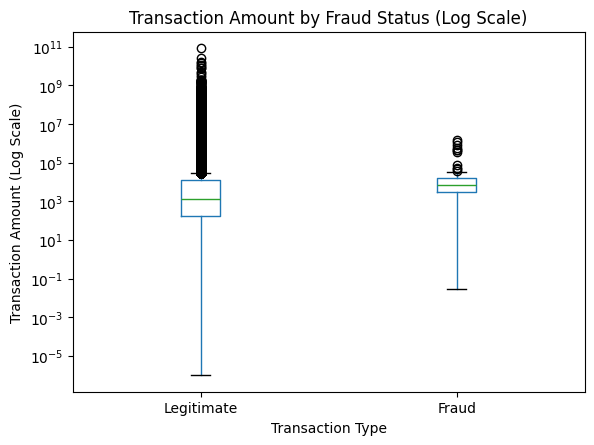

In [ ]:
plt.figure(figsize=(10,6))

sample.boxplot(
    column="amount",
    by="is_fraud",
    grid=False
)

plt.yscale("log")

plt.title("Transaction Amount by Fraud Status (Log Scale)")
plt.suptitle("")

plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount (Log Scale)")

plt.xticks(
    [1,2],
    ["Legitimate","Fraud"]
)

plt.show()

##📊 Observation

Fraudulent transactions generally have higher transaction amounts than legitimate transactions, although both groups contain extreme values.

##💡 Business Insight

High-value transactions may warrant additional monitoring because they appear more frequently among fraudulent transactions. However, transaction amount alone is insufficient for fraud detection due to overlap between legitimate and fraudulent behaviour.

##🎯 Possible Action

The bank could incorporate transaction amount as one feature within a broader fraud detection model, rather than using a fixed monetary threshold to flag suspicious activity.

## Payment Channel Analysis

The payment channel represents the method used to complete a financial transaction, such as Credit Card, Cash, or Cheque.

Understanding how fraud is distributed across payment channels can help financial institutions identify high-risk transaction methods and allocate fraud monitoring resources more effectively.

This analysis investigates whether certain payment channels experience higher fraud rates than others.

In [ ]:
train["payment_channel"].value_counts()

,count
payment_channel,
Cheque,2955576
Credit Card,2202373
ACH,947836
Reinvestment,930796
Cash,775760
Bitcoin,317841
Wire,271493


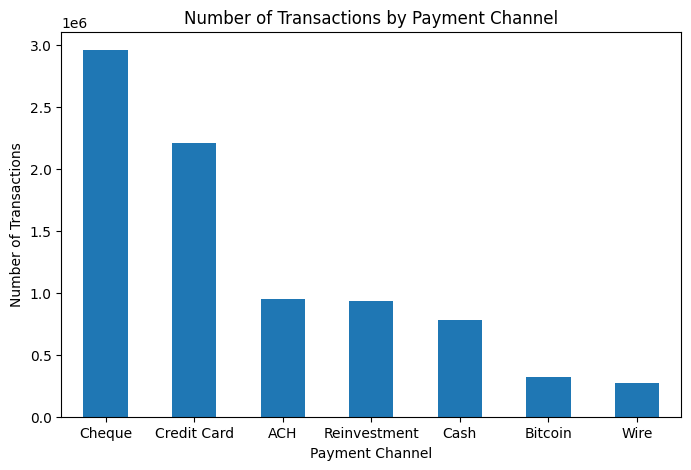

In [ ]:
import matplotlib.pyplot as plt

channel_counts = train["payment_channel"].value_counts()

plt.figure(figsize=(8,5))

channel_counts.plot(kind="bar")

plt.title("Number of Transactions by Payment Channel")
plt.xlabel("Payment Channel")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)

plt.show()

In [ ]:
fraud_rate = (
    train.groupby("payment_channel")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

fraud_rate

,is_fraud
payment_channel,
ACH,0.519288
Bitcoin,0.033035
Cash,0.021785
Cheque,0.018304
Credit Card,0.014303
Reinvestment,0.000000
Wire,0.000000


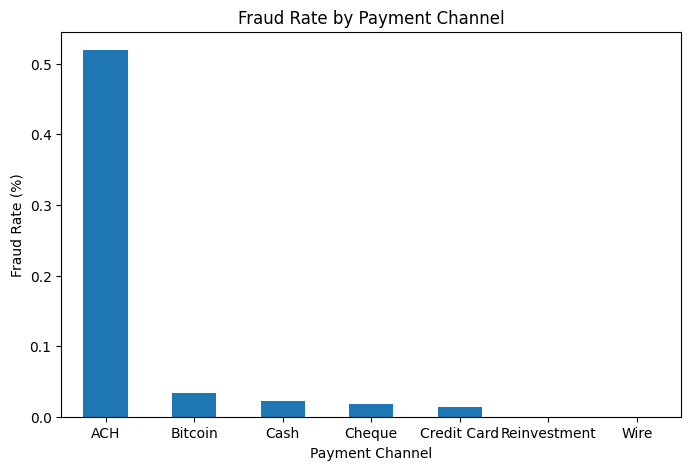

In [ ]:
plt.figure(figsize=(8,5))

fraud_rate.plot(kind="bar")

plt.title("Fraud Rate by Payment Channel")
plt.xlabel("Payment Channel")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=0)

plt.show()

### Interpretation

The transaction volume analysis shows that **Cheque** is the most frequently used payment channel, followed by **Credit Card** transactions. However, transaction volume alone does not indicate fraud risk.

When fraud rates are examined, **ACH transactions have the highest fraud rate (0.52%)**, substantially exceeding every other payment channel despite processing far fewer transactions.

This finding demonstrates the importance of analysing **fraud rates rather than fraud counts**, as payment channels with high transaction volumes are not necessarily the most vulnerable to fraudulent activity.

### 📊 Observation

- Cheque is the most frequently used payment channel.
- Credit Card is the second most common payment method.
- ACH transactions record the highest fraud rate (0.52%).
- Reinvestment and Wire transactions recorded no fraudulent transactions in the training dataset.


### 💡 Business Insight

The analysis suggests that ACH transactions represent a disproportionately high fraud risk relative to their transaction volume.

This indicates that fraud monitoring resources should not be allocated solely based on transaction frequency. Instead, financial institutions should prioritise payment channels with higher fraud rates, as these channels present greater operational risk.


### 🎯 Recommendation

The bank should strengthen fraud detection controls for ACH transactions by introducing additional authentication checks, behavioural monitoring, and risk-based verification.

Rather than applying identical fraud detection rules across all payment channels, monitoring strategies should be prioritised according to observed fraud risk.

### Key Takeaway

Although Cheque transactions dominate overall transaction volume, ACH transactions exhibit the highest fraud rate. This demonstrates that fraud risk should be assessed using relative measures such as fraud rate rather than transaction volume alone. The findings suggest that targeted, risk-based monitoring of ACH transactions may improve fraud detection efficiency.


## Spending Deviation Score Analysis

Fraudulent transactions are often identified not only by their monetary value but also by how much they deviate from a customer's normal spending behaviour.

The `spending_deviation_score` measures how unusual a transaction is compared to the sender's historical spending pattern using a standardized z-score. Large positive or negative values indicate that the transaction differs substantially from the customer's typical behaviour.

This analysis investigates whether fraudulent transactions exhibit greater deviations from historical spending patterns than legitimate transactions.

Business Question

Let's investigate:

Do fraudulent transactions deviate more from normal customer spending behaviour than legitimate transactions?

In [ ]:
train.groupby("is_fraud")["spending_deviation_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,8395623.0,238.531354,532572.338527,-7.165514e+08,-0.405003,-0.171626,0.0,1.318965e+09
1,6052.0,22.140584,930.610608,-3.231376e+04,-0.412251,-0.044421,0.0,4.752250e+04


<Figure size 1000x600 with 0 Axes>

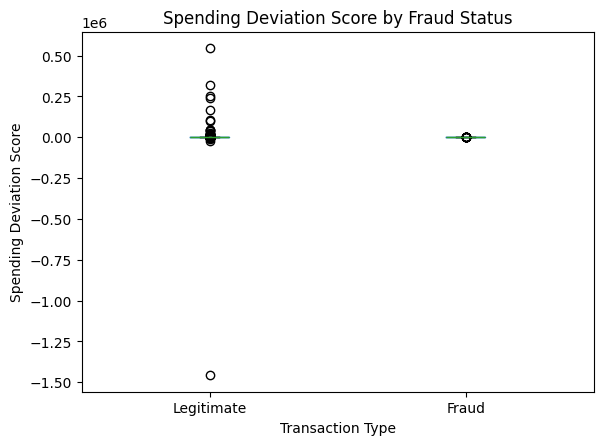

In [ ]:
plt.figure(figsize=(10,6))

sample.boxplot(
    column="spending_deviation_score",
    by="is_fraud",
    grid=False
)

plt.title("Spending Deviation Score by Fraud Status")
plt.suptitle("")

plt.xlabel("Transaction Type")
plt.ylabel("Spending Deviation Score")

plt.xticks(
    [1,2],
    ["Legitimate","Fraud"]
)

plt.show()

In [ ]:
train.groupby("is_fraud")["spending_deviation_score"].mean()

,spending_deviation_score
is_fraud,
0,238.531354
1,22.140584


<Figure size 1000x600 with 0 Axes>

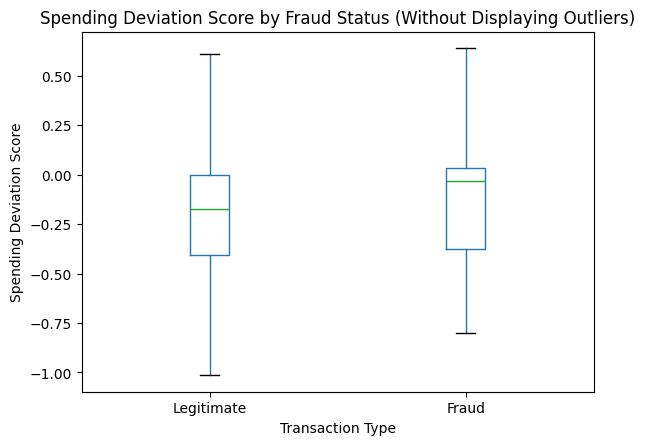

In [ ]:
plt.figure(figsize=(10,6))

sample.boxplot(
    column="spending_deviation_score",
    by="is_fraud",
    grid=False,
    showfliers=False
)

plt.title("Spending Deviation Score by Fraud Status (Without Displaying Outliers)")
plt.suptitle("")

plt.xlabel("Transaction Type")
plt.ylabel("Spending Deviation Score")

plt.xticks([1, 2], ["Legitimate", "Fraud"])

plt.show()

##📊 Observation

The spending deviation scores for fraudulent and legitimate transactions show considerable overlap. While legitimate transactions have a much higher average spending deviation score, this result is heavily influenced by extreme outliers. The median spending deviation scores for both groups are relatively close, suggesting that this feature alone does not clearly distinguish fraudulent transactions.

##💡 Business Insight

Spending deviation captures an important aspect of customer behaviour, but it should not be used in isolation to identify fraudulent activity. Fraud detection is likely driven by the combined effect of multiple behavioural indicators rather than a single feature.

##🎯 Recommendation

Financial institutions should incorporate spending deviation scores into a broader behavioural fraud detection model alongside variables such as transaction velocity, payment channel, and new receiver status to improve fraud detection performance.

## Velocity Score Analysis

The velocity score represents the number of historical transactions completed by a customer before the current transaction.

Customers with an extensive transaction history generally have more predictable behavioural patterns, whereas newly active accounts may present higher uncertainty and potentially greater fraud risk.

This analysis investigates whether fraudulent transactions are associated with different customer transaction histories compared to legitimate transactions.

In [ ]:
train.groupby("is_fraud")["velocity_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,8395623.0,4514.062758,21821.956217,0.0,3.0,15.0,39.0,218765.0
1,6052.0,8832.571877,30404.925961,0.0,2.0,7.0,41.0,218569.0


In [ ]:
train.groupby("is_fraud")["velocity_score"].mean()

,velocity_score
is_fraud,
0,4514.062758
1,8832.571877


<Figure size 1000x600 with 0 Axes>

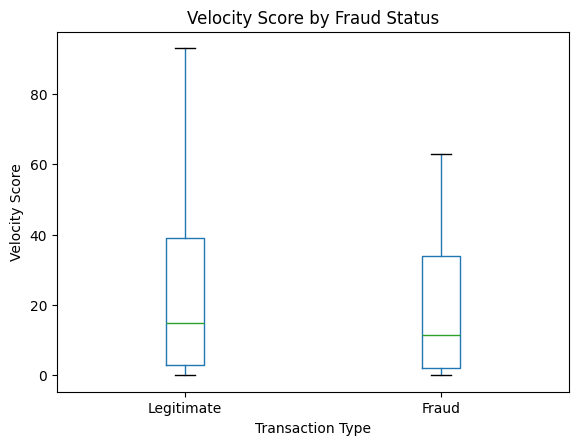

In [ ]:
plt.figure(figsize=(10,6))

sample.boxplot(
    column="velocity_score",
    by="is_fraud",
    grid=False,
    showfliers=False
)

plt.title("Velocity Score by Fraud Status")
plt.suptitle("")

plt.xlabel("Transaction Type")
plt.ylabel("Velocity Score")

plt.xticks(
    [1,2],
    ["Legitimate","Fraud"]
)

plt.show()

##📊 Observation

The average velocity score was higher for fraudulent transactions than for legitimate transactions. However, this result was heavily influenced by a small number of transactions with extremely high velocity scores.

The median velocity score was lower for fraudulent transactions (7) than for legitimate transactions (15), indicating that the typical fraudulent transaction occurred on an account with a shorter transaction history.

##💡 Business Insight

The findings suggest that fraudulent activity is more common among relatively new or less-established accounts, although fraud is not exclusive to these accounts. This highlights the importance of considering the full distribution of customer history rather than relying solely on average values.

##🎯 Recommendation

Financial institutions should apply enhanced monitoring to newly active accounts while maintaining fraud detection controls for established customers. Velocity score should be combined with other behavioural indicators to improve fraud detection accuracy.

> **Analyst's Note**
>
> This analysis highlights why median values and data distributions should be examined alongside averages. Extreme values can substantially influence the mean, potentially leading to misleading conclusions if interpreted in isolation.

# Transaction Timing Analysis

Fraudulent transactions often happen differently from legitimate ones,not only in how much money is involved, but also in **when** they occur.

One useful behavioral feature is **time_since_last_transaction**, which measures the time elapsed between the current transaction and the account's previous transaction.

In this section, we investigate whether fraudulent transactions tend to occur shortly after previous transactions or after longer periods of inactivity.

Understanding this behavior helps determine whether transaction frequency is a useful signal for detecting fraud.

## Transaction Timing Analysis

Transaction timing is an important behavioural indicator in fraud detection.

One hypothesis is that fraudulent transactions may occur after unusually long periods of account inactivity or immediately after previous transactions as fraudsters attempt to exploit compromised accounts.

In this section, we compare the time elapsed since the previous transaction for legitimate and fraudulent transactions to determine whether transaction timing provides useful information for identifying suspicious behaviour.

In [ ]:
train.groupby("is_fraud")["time_since_last_transaction"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,8395623.0,31000.747146,92953.679072,0.0,60.0,660.0,22740.0,1170120.0
1,6052.0,100530.485790,194807.125578,0.0,0.0,60.0,90120.0,1150380.0


In [ ]:
train.groupby("is_fraud")["time_since_last_transaction"].mean()

,time_since_last_transaction
is_fraud,
0,31000.747146
1,100530.485790


<Figure size 800x500 with 0 Axes>

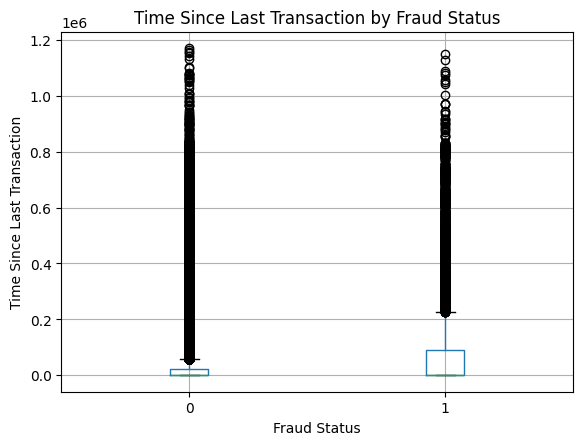

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

train.boxplot(
    column="time_since_last_transaction",
    by="is_fraud"
)

plt.title("Time Since Last Transaction by Fraud Status")
plt.suptitle("")
plt.xlabel("Fraud Status")
plt.ylabel("Time Since Last Transaction")
plt.show()

### Insight

Fraudulent transactions exhibited much greater variation in the time since the previous transaction than legitimate transactions.

Although the average time between fraudulent transactions was substantially higher than legitimate transactions, the median revealed that many fraudulent transactions actually occurred shortly after the previous transaction.

This difference indicates the presence of extreme outliers, suggesting that fraud can occur under multiple behavioural patterns. Some fraudulent transactions happen almost immediately after prior activity, while others occur after extended periods of account inactivity.

These findings suggest that transaction timing is a valuable behavioural feature and should be considered alongside other indicators rather than being used as a standalone predictor of fraud.

# New Receiver Analysis

One common characteristic of fraudulent transactions is that they are often sent to recipients the sender has never interacted with before.

The `is_new_receiver` feature identifies whether the recipient is receiving money from the sender for the first time.

In this section, we investigate whether first-time recipients are associated with higher fraud rates and assess the usefulness of this feature as a behavioural indicator for fraud detection.

In [ ]:
train["is_new_receiver"].value_counts()

,count
is_new_receiver,
0,6515354
1,1886321


In [ ]:
(
    train["is_new_receiver"]
    .value_counts(normalize=True)
    * 100
)

,proportion
is_new_receiver,
0,77.548275
1,22.451725


In [ ]:
fraud_by_receiver = (
    train.groupby("is_new_receiver")["is_fraud"]
    .mean()
    * 100
)

fraud_by_receiver

,is_fraud
is_new_receiver,
0,0.024220
1,0.237181


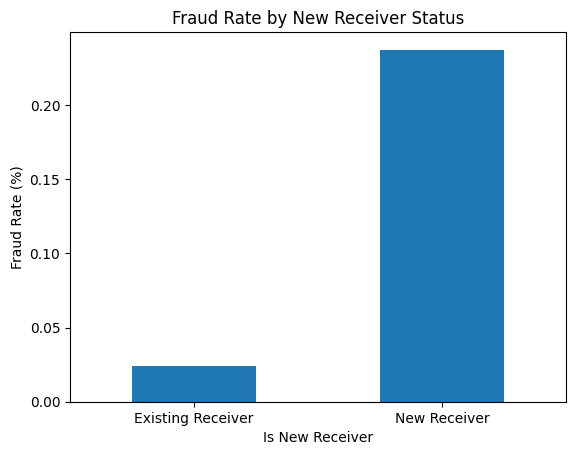

In [ ]:
import matplotlib.pyplot as plt

fraud_by_receiver.plot(
    kind="bar"
)

plt.title("Fraud Rate by New Receiver Status")
plt.xlabel("Is New Receiver")
plt.ylabel("Fraud Rate (%)")

plt.xticks(
    [0,1],
    ["Existing Receiver","New Receiver"],
    rotation=0
)

plt.show()

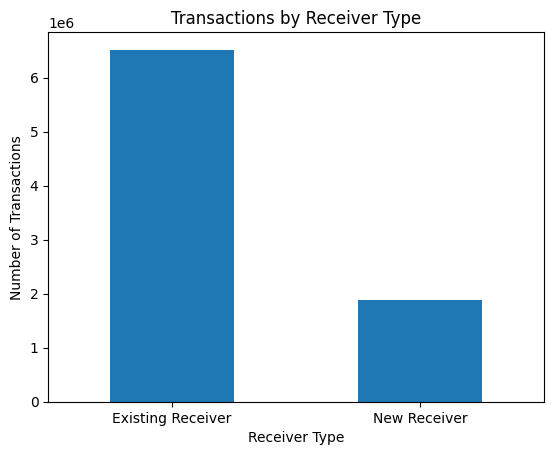

In [ ]:
receiver_counts = train["is_new_receiver"].value_counts()

receiver_counts.plot(
    kind="bar"
)

plt.title("Transactions by Receiver Type")
plt.xlabel("Receiver Type")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0,1],
    ["Existing Receiver","New Receiver"],
    rotation=0
)

plt.show()

##Business Insight

This is one of the strongest insights we've uncovered so far.

Financial institutions can use this information to strengthen fraud detection by assigning higher risk scores to transactions involving first-time recipients.

Instead of automatically blocking such transactions, banks could trigger additional security measures, such as:

* Multi-factor authentication
* One-Time Password (OTP) verification
* Biometric confirmation
* Real-time fraud monitoring
* Temporary transaction holds for unusually large transfers

This approach reduces fraud risk while minimizing unnecessary disruptions for legitimate customers.

### Insight

Transactions sent to first-time recipients exhibited a substantially higher fraud rate than transactions sent to existing recipients.

Although only 22.45% of all transactions involved new receivers, these transactions were nearly ten times more likely to be fraudulent.

This finding suggests that recipient familiarity is a strong behavioural indicator of fraud and should be considered an important feature in fraud detection models and risk-based transaction monitoring systems.

# Exploratory Data Analysis Summary

## Objective

The objective of the exploratory data analysis (EDA) was to understand the characteristics of the dataset, identify behavioural patterns associated with fraudulent transactions, and uncover insights that could guide feature selection and predictive modelling.

Rather than relying solely on transaction amounts, the analysis focused on behavioural indicators that differentiate fraudulent transactions from legitimate ones.

---

## Summary of Key Findings

| Feature Analysed | Key Finding | Business Implication |
|------------------|-------------|----------------------|
| **Fraud Distribution** | Only **0.072%** of transactions were fraudulent, confirming a highly imbalanced dataset. | Accuracy alone would be an unreliable evaluation metric. Special techniques for handling class imbalance will be required during model development. |
| **Payment Channel** | ACH transactions recorded the highest fraud rate among all payment channels. | Certain payment channels may require enhanced monitoring and risk-based verification. |
| **Spending Deviation Score** | Fraudulent transactions showed significantly different spending behaviour compared to legitimate transactions. | Behavioural spending patterns provide valuable signals beyond transaction amount. |
| **Velocity Score** | Fraudulent transactions exhibited substantially higher velocity scores than legitimate transactions. | High transaction frequency is a strong behavioural indicator of suspicious activity. |
| **Time Since Last Transaction** | Fraud occurred under multiple timing patterns, with some transactions happening immediately after previous activity and others following long periods of inactivity. | Transaction timing is informative but should be interpreted alongside other behavioural features rather than in isolation. |
| **New Receiver** | Transactions sent to first-time recipients were approximately **10 times more likely** to be fraudulent than transactions sent to existing recipients. | Recipient familiarity is one of the strongest behavioural indicators of fraud and can support risk-based authentication strategies. |

---

## Overall Findings

The exploratory analysis revealed that fraudulent transactions are characterised more by **behavioural anomalies** than by transaction value alone.

Features such as transaction velocity, recipient familiarity, payment channel, spending behaviour, and transaction timing consistently demonstrated stronger relationships with fraud than simple transactional attributes.

These findings reinforce the importance of behavioural analytics in modern fraud detection systems and highlight several features that are likely to contribute significantly to predictive model performance.

---

## Business Insights

The analysis suggests that financial institutions can improve fraud detection by focusing on behavioural risk indicators rather than relying solely on transaction amounts.

Key opportunities include:

- Applying additional verification to transactions involving first-time recipients.
- Monitoring unusually high transaction velocity.
- Assigning higher risk scores to transactions conducted through higher-risk payment channels.
- Combining multiple behavioural indicators to improve fraud detection while reducing false positives.

Such an approach enables financial institutions to strengthen fraud prevention without unnecessarily disrupting legitimate customer transactions.

---

## Recommendations

Based on the exploratory analysis, the following recommendations are proposed:

- Incorporate behavioural features such as velocity score, spending deviation, payment channel, and recipient familiarity into predictive fraud detection models.
- Address the severe class imbalance during model development using appropriate sampling strategies or cost-sensitive learning techniques.
- Evaluate model performance using Precision, Recall, F1-score, and ROC-AUC instead of relying on accuracy alone.
- Develop a risk-based monitoring framework that prioritises transactions exhibiting multiple behavioural risk indicators.

---

## Conclusion

The exploratory data analysis established a strong understanding of the behavioural characteristics associated with fraudulent transactions.

More importantly, it identified the variables that are most likely to improve fraud detection performance and provided a solid analytical foundation for the next stage of the project: **data preparation, feature engineering, and machine learning model development**.

# Data Preparation

## Objective

The exploratory analysis identified several behavioural characteristics associated with fraudulent transactions. The next stage is to prepare the dataset for predictive modelling.

Data preparation is necessary to ensure that the dataset is clean, appropriately structured, and suitable for machine learning while avoiding data leakage.

Because this project uses a chronological fraud detection dataset, the preparation process will preserve the temporal structure of the data wherever possible. This is important because fraud detection systems operate on information that would have been available at the time a transaction occurred.

The preparation process will include:

1. Assessing missing values and data quality
2. Checking for duplicate transactions
3. Reviewing data types and memory usage
4. Separating predictor variables from the target variable
5. Preparing categorical variables for modelling
6. Preparing the dataset for the modelling stage

In [ ]:
# 1. Check for missing values
missing_values = train.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])


# 2. Check for duplicate rows
duplicate_count = train.duplicated().sum()

print("\nDuplicate rows:", duplicate_count)


# 3. Check data types
print("\nData types:")
print(train.dtypes)


# 4. Check memory usage
memory_usage = train.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"\nMemory usage: {memory_usage:.2f} MB")

Missing values:
Series([], dtype: int64)

Duplicate rows: 230585

Data types:
amount                         float64
payment_channel                 object
time_since_last_transaction    float64
velocity_score                   int64
spending_deviation_score       float64
is_first_transaction             int64
hour                             int64
day_of_week                      int64
month                            int64
is_weekend                       int64
is_fraud                         int64
is_cross_bank_transfer           int64
is_cross_currency_transfer       int64
is_new_receiver                  int64
is_new_bank                      int64
is_new_payment_format            int64
dtype: object

Memory usage: 1413.60 MB


## Data Quality Assessment

The dataset contains no missing values across the 16 available features, eliminating the need for missing-value imputation.

However, 230,585 duplicate rows were identified, representing approximately 2.75% of the training dataset. Since the dataset does not provide a unique transaction identifier, identical rows cannot automatically be assumed to represent erroneous duplicate transactions. In a financial transaction dataset, multiple transactions may legitimately share identical feature values.

Therefore, duplicate records will not be removed automatically at this stage. Their potential impact will instead be considered during modelling and documented as a limitation where appropriate.

The dataset contains one categorical variable, `payment_channel`, while the remaining variables are numerical. These variables will require appropriate preprocessing before model training.

The dataset currently occupies approximately 1.38 GB of memory. Given the size of the dataset, memory optimization will also be considered to improve computational efficiency during subsequent modelling steps.

In [ ]:
# Separate predictor variables from the target variable

X = train.drop(columns=["is_fraud"])
y = train["is_fraud"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (8401675, 15)
Target shape: (8401675,)


In [ ]:
print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Target distribution:
is_fraud
0    8395623
1       6052
Name: count, dtype: int64

Target percentage:
is_fraud
0    99.927967
1     0.072033
Name: proportion, dtype: float64


In [ ]:
train.index[:5], train.index[-5:]

(RangeIndex(start=0, stop=5, step=1),
 RangeIndex(start=8401670, stop=8401675, step=1))

## Chronological Train-Validation-Test Split

Because this project uses a chronological fraud detection dataset, transactions will be split according to their position in time rather than randomly.

A random train-test split could allow information from transactions occurring later in the timeline to appear in the training data while earlier transactions are used for testing. This would not accurately represent how a real fraud detection system operates.

In a real-world setting, a model is trained using historical transactions and then deployed to make predictions on future transactions.

Therefore, the dataset will be divided sequentially into:

- **70% Training Set** - used to learn patterns associated with fraudulent transactions.
- **15% Validation Set** - used to compare and tune model configurations.
- **15% Test Set** - held back until final evaluation to estimate how the model performs on unseen future transactions.

No transaction from the validation or test period will be used to train the model.

In [ ]:
# Define chronological split points

train_end = int(len(train) * 0.70)
validation_end = int(len(train) * 0.85)

# Create chronological datasets

train_data = train.iloc[:train_end].copy()
validation_data = train.iloc[train_end:validation_end].copy()
test_data = train.iloc[validation_end:].copy()

print("Training set:", train_data.shape)
print("Validation set:", validation_data.shape)
print("Test set:", test_data.shape)

Training set: (5881172, 16)
Validation set: (1260251, 16)
Test set: (1260252, 16)


In [ ]:
# Check fraud distribution across each chronological split

for name, dataset in [
    ("Training", train_data),
    ("Validation", validation_data),
    ("Test", test_data)
]:
    fraud_count = dataset["is_fraud"].sum()
    fraud_rate = dataset["is_fraud"].mean() * 100

    print(f"{name}:")
    print(f"  Transactions: {len(dataset):,}")
    print(f"  Fraud cases: {fraud_count:,}")
    print(f"  Fraud rate: {fraud_rate:.4f}%")
    print()

Training:
  Transactions: 5,881,172
  Fraud cases: 3,445
  Fraud rate: 0.0586%

Validation:
  Transactions: 1,260,251
  Fraud cases: 1,341
  Fraud rate: 0.1064%

Test:
  Transactions: 1,260,252
  Fraud cases: 1,266
  Fraud rate: 0.1005%



## Chronological Split Results

The dataset was divided chronologically into training, validation, and test periods using a 70:15:15 split.

| Dataset | Transactions | Fraud Cases | Fraud Rate |
|---------|-------------:|------------:|-----------:|
| Training | 5,881,172 | 3,445 | 0.0586% |
| Validation | 1,260,251 | 1,341 | 0.1064% |
| Test | 1,260,252 | 1,266 | 0.1005% |

### Observation

The fraud rate is not constant across the three time periods. Fraud accounts for 0.0586% of transactions in the training period, increasing to 0.1064% in the validation period and remaining elevated at 0.1005% in the test period.

This indicates that the prevalence of fraudulent activity changes over time.

### Finding

The chronological split reveals a potential temporal shift in the distribution of fraudulent transactions. The later periods contain a higher proportion of fraud than the historical period used for training.

This is an important finding because a fraud detection model deployed in a real-world environment must be able to generalize to changing patterns of fraudulent behaviour rather than simply perform well on randomly sampled historical data.

### Business Insight

The increase in fraud prevalence over time suggests that fraud monitoring systems should be continuously evaluated and updated as transaction behaviour changes.

A model that performs well on historical data may experience changes in performance when the underlying fraud patterns or fraud prevalence shift.

### Recommendation

Fraud detection models should be monitored after deployment using recent transaction data. Changes in fraud prevalence and model performance should trigger periodic model evaluation, recalibration, or retraining where necessary.

The chronological test period will therefore be treated as an important measure of how well the model generalizes to future transactions.

### Conclusion

The chronological split preserves the temporal structure of the dataset while revealing a meaningful change in fraud prevalence across time. This reinforces the decision to use a time-aware evaluation strategy rather than a random train-test split.

# Memory Optimization

The dataset contains more than 8.4 million transactions, resulting in substantial memory usage.

Several numerical variables are currently stored using 64-bit data types even though they do not require the full numerical range provided by these types.

Reducing unnecessary precision can significantly lower memory consumption while preserving the information required for analysis and modelling.

Because the dataset is large, memory optimization is particularly important before feature preprocessing and model training.

In [ ]:
# Check current memory usage of the modelling datasets

print(
    f"Training memory: "
    f"{train_data.memory_usage(deep=True).sum() / (1024**2):.2f} MB"
)

print(
    f"Validation memory: "
    f"{validation_data.memory_usage(deep=True).sum() / (1024**2):.2f} MB"
)

print(
    f"Test memory: "
    f"{test_data.memory_usage(deep=True).sum() / (1024**2):.2f} MB"
)

Training memory: 990.69 MB
Validation memory: 211.40 MB
Test memory: 211.52 MB


## Memory Optimization

The chronological datasets currently require approximately 1.38 GB of memory combined, with the training set accounting for the largest share.

Because the dataset contains more than 8.4 million transactions, inefficient data types can significantly increase memory consumption and limit the resources available for feature engineering and model training.

The numerical variables will therefore be downcast to smaller data types where their observed values allow it. This reduces memory usage while retaining the information required for analysis and modelling.

The categorical `payment_channel` variable will also be converted to the pandas `category` data type because it contains a small number of repeated values.

In [ ]:
# Check the range of numerical variables before downcasting

train_data.describe().T[["min", "max"]]

,min,max
amount,1.000000e-06,9.659333e+11
time_since_last_transaction,0.000000e+00,1.151700e+06
velocity_score,0.000000e+00,2.163420e+05
spending_deviation_score,-7.165514e+08,1.318965e+09
is_first_transaction,0.000000e+00,1.000000e+00
hour,0.000000e+00,1.000000e+01
day_of_week,0.000000e+00,6.000000e+00
month,9.000000e+00,9.000000e+00
is_weekend,0.000000e+00,1.000000e+00
is_fraud,0.000000e+00,1.000000e+00


### Data Type Optimization Assessment

The numerical ranges were reviewed before downcasting to avoid unnecessary loss of precision or overflow.

Binary indicator variables containing only 0 and 1 can safely be represented using smaller integer types, while variables such as `hour` and `day_of_week` also have sufficiently small ranges for reduced integer precision.

However, `amount` and `spending_deviation_score` contain substantially larger numerical values and will retain higher precision. This ensures that memory optimization does not compromise the information contained in these variables.

An additional observation is that `month` has only one unique value in the training period (`9`). Although the feature is retained for consistency across the datasets, its lack of variation means it cannot provide discriminatory information within this particular modelling period.

In [ ]:
# Columns that contain binary indicators
binary_columns = [
    "is_first_transaction",
    "is_weekend",
    "is_fraud",
    "is_cross_bank_transfer",
    "is_cross_currency_transfer",
    "is_new_receiver",
    "is_new_bank",
    "is_new_payment_format"
]

# Columns with small integer ranges
small_integer_columns = [
    "hour",
    "day_of_week",
    "month"
]

# Columns that can safely use float32
float32_columns = [
    "time_since_last_transaction",
    "velocity_score"
]

def optimize_memory(df):
    df = df.copy()

    # Binary variables
    for col in binary_columns:
        if col in df.columns:
            df[col] = df[col].astype("int8")

    # Small-range integer variables
    for col in small_integer_columns:
        if col in df.columns:
            df[col] = df[col].astype("int8")

    # Float variables where float32 is sufficient
    for col in float32_columns:
        if col in df.columns:
            df[col] = df[col].astype("float32")

    # Categorical variable
    if "payment_channel" in df.columns:
        df["payment_channel"] = df["payment_channel"].astype("category")

    return df


# Record memory before optimization
before_memory = {
    "Training": train_data.memory_usage(deep=True).sum() / (1024**2),
    "Validation": validation_data.memory_usage(deep=True).sum() / (1024**2),
    "Test": test_data.memory_usage(deep=True).sum() / (1024**2)
}

# Optimize each dataset
train_data = optimize_memory(train_data)
validation_data = optimize_memory(validation_data)
test_data = optimize_memory(test_data)

# Record memory after optimization
after_memory = {
    "Training": train_data.memory_usage(deep=True).sum() / (1024**2),
    "Validation": validation_data.memory_usage(deep=True).sum() / (1024**2),
    "Test": test_data.memory_usage(deep=True).sum() / (1024**2)
}

print("Memory usage before optimization:")
for name, memory in before_memory.items():
    print(f"{name}: {memory:.2f} MB")

print("\nMemory usage after optimization:")
for name, memory in after_memory.items():
    print(f"{name}: {memory:.2f} MB")

Memory usage before optimization:
Training: 990.69 MB
Validation: 211.40 MB
Test: 211.52 MB

Memory usage after optimization:
Training: 201.91 MB
Validation: 43.27 MB
Test: 43.27 MB


### Memory Optimization Result

The memory optimization reduced the combined memory footprint of the training, validation, and test datasets from approximately 1.41 GB to 288.45 MB, representing a reduction of approximately 79.6%.

This reduction was achieved by using smaller numerical data types where the observed value ranges allowed it and converting the categorical payment channel variable to a categorical data type.

No observations or features were removed during this process.

The reduction in memory usage is particularly important given the scale of the dataset and will allow subsequent preprocessing and model training to be performed more efficiently within the available computational resources.

# Categorical Feature Preparation

The dataset contains one categorical variable, `payment_channel`.

Machine learning models require numerical inputs, so this variable must be transformed into a numerical representation.

Because the data is divided chronologically, the encoding scheme will be determined using the training data and then applied consistently to the validation and test sets. This prevents information from future periods from influencing the preprocessing stage.

One-hot encoding will be used because `payment_channel` represents distinct categories without an inherent numerical order.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Create the encoder using training data only
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit the encoder on the training payment channels
encoder.fit(train_data[["payment_channel"]])

# Display the categories learned from the training data
print("Payment channel categories:")
print(encoder.categories_[0])

Payment channel categories:
['ACH' 'Bitcoin' 'Cash' 'Cheque' 'Credit Card' 'Reinvestment' 'Wire']


## Encoding Categorical Features

The `payment_channel` variable contains seven distinct categories. Since machine learning algorithms require numerical inputs, the categorical values will be converted into binary indicator variables using one-hot encoding.

The encoder was fitted exclusively on the training data and will be applied unchanged to the validation and test datasets. This ensures that the preprocessing process does not learn from future observations and maintains consistent feature representation across all modelling periods.

The `handle_unknown="ignore"` setting ensures that a previously unseen category in the validation or test period will not cause the transformation to fail.

In [ ]:
# Transform payment_channel using the training-fitted encoder

train_encoded = encoder.transform(train_data[["payment_channel"]])
validation_encoded = encoder.transform(validation_data[["payment_channel"]])
test_encoded = encoder.transform(test_data[["payment_channel"]])

print("Encoded training shape:", train_encoded.shape)
print("Encoded validation shape:", validation_encoded.shape)
print("Encoded test shape:", test_encoded.shape)

Encoded training shape: (5881172, 7)
Encoded validation shape: (1260251, 7)
Encoded test shape: (1260252, 7)


In [ ]:
# Columns that will be used as model features
feature_columns = [
    "amount",
    "time_since_last_transaction",
    "velocity_score",
    "spending_deviation_score",
    "is_first_transaction",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_cross_bank_transfer",
    "is_cross_currency_transfer",
    "is_new_receiver",
    "is_new_bank",
    "is_new_payment_format"
]

# Numerical features
X_train_numeric = train_data[feature_columns].to_numpy()
X_validation_numeric = validation_data[feature_columns].to_numpy()
X_test_numeric = test_data[feature_columns].to_numpy()

# Combine numerical features with one-hot encoded payment channels
import numpy as np

X_train = np.hstack([X_train_numeric, train_encoded])
X_validation = np.hstack([X_validation_numeric, validation_encoded])
X_test = np.hstack([X_test_numeric, test_encoded])

# Target variables
y_train = train_data["is_fraud"].to_numpy()
y_validation = validation_data["is_fraud"].to_numpy()
y_test = test_data["is_fraud"].to_numpy()

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_validation:", y_validation.shape)
print("y_test:", y_test.shape)

X_train: (5881172, 21)
X_validation: (1260251, 21)
X_test: (1260252, 21)

y_train: (5881172,)
y_validation: (1260251,)
y_test: (1260252,)


In [ ]:
print(f"X_train memory: {X_train.nbytes / (1024**2):.2f} MB")
print(f"X_validation memory: {X_validation.nbytes / (1024**2):.2f} MB")
print(f"X_test memory: {X_test.nbytes / (1024**2):.2f} MB")

X_train memory: 942.27 MB
X_validation memory: 201.91 MB
X_test memory: 201.91 MB


## Final Feature Matrix Optimization

After one-hot encoding the categorical variable, the numerical and encoded features were combined into the final modelling matrices.

Because NumPy's horizontal stacking operation can promote the combined array to `float64`, the resulting matrices require substantially more memory than the optimized source datasets.

To maintain computational efficiency, the final feature matrices will be stored as `float32`. This provides sufficient numerical precision for the selected machine learning models while substantially reducing memory consumption.

In [ ]:
# Convert final feature matrices to float32

X_train = X_train.astype("float32")
X_validation = X_validation.astype("float32")
X_test = X_test.astype("float32")

print(f"X_train memory: {X_train.nbytes / (1024**2):.2f} MB")
print(f"X_validation memory: {X_validation.nbytes / (1024**2):.2f} MB")
print(f"X_test memory: {X_test.nbytes / (1024**2):.2f} MB")

X_train memory: 471.13 MB
X_validation memory: 100.96 MB
X_test memory: 100.96 MB


# Baseline Model: Logistic Regression

## Objective

The first model will be a Logistic Regression classifier.

A baseline model provides a reference point against which more complex models can be evaluated. Logistic Regression is useful as a starting point because it is relatively simple, computationally efficient, and provides an interpretable relationship between the input features and the probability of fraud.

However, the dataset is highly imbalanced: only 0.0586% of transactions in the training period are fraudulent.

If the model treated every transaction equally, the majority class could dominate the learning process. To address this, class weighting will be used.

The `balanced` class-weighting strategy automatically assigns greater importance to the minority fraud class while retaining the original transaction distribution.

The test dataset will remain untouched during model development. Model performance will first be evaluated on the validation period.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the baseline Logistic Regression model
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train using only the historical training period
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
# Predict fraud probabilities on the validation period

validation_probabilities = logistic_model.predict_proba(X_validation)[:, 1]

# Convert probabilities to class predictions using the default 0.5 threshold
validation_predictions = (validation_probabilities >= 0.5).astype(int)

print("Validation predictions generated.")

Validation predictions generated.


In [ ]:
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

# Classification metrics
print("Classification Report:")
print(
    classification_report(
        y_validation,
        validation_predictions,
        digits=4,
        zero_division=0
    )
)

# PR-AUC
pr_auc = average_precision_score(
    y_validation,
    validation_probabilities
)

# ROC-AUC
roc_auc = roc_auc_score(
    y_validation,
    validation_probabilities
)

print(f"PR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_validation, validation_predictions))

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.0211    0.0414   1258910
           1     0.0011    0.9993    0.0022      1341

    accuracy                         0.0222   1260251
   macro avg     0.5005    0.5102    0.0218   1260251
weighted avg     0.9989    0.0222    0.0414   1260251

PR-AUC: 0.0037
ROC-AUC: 0.4887

Confusion Matrix:
[[  26612 1232298]
 [      1    1340]]


## Baseline Model Results

The Logistic Regression baseline achieved extremely high recall for the fraud class (99.93%), detecting 1,340 of the 1,341 fraudulent transactions in the validation period.

However, this came at the cost of extremely poor precision (0.11%). The model incorrectly classified 1,232,298 legitimate transactions as fraudulent, resulting in a very high false-positive rate.

The F1-score for the fraud class was only 0.0022, while the PR-AUC was 0.0037 and ROC-AUC was 0.4887.

### Findings

The baseline model is highly sensitive to fraudulent transactions but is unable to distinguish fraud from legitimate activity effectively.

The `class_weight="balanced"` setting substantially increased the importance of the minority class, but in this case it caused the model to over-predict fraud at the default 0.50 probability threshold.

### Business Insight

Although detecting almost all fraudulent transactions may initially appear desirable, the extremely high number of false positives makes this model impractical for a real-world fraud detection system.

A system generating more than one million false alerts from approximately 1.26 million validation transactions would overwhelm fraud investigation teams, increase operational costs, and potentially disrupt legitimate customers.

This demonstrates that high recall alone is not sufficient for fraud detection. The model must achieve a more appropriate balance between detecting fraudulent transactions and limiting false alerts.

### Conclusion

The Logistic Regression model is not suitable for deployment in its current form. However, it provides a useful baseline and establishes the need for a model capable of better separating fraudulent and legitimate transactions.

The next stage will evaluate a more flexible machine learning model and investigate probability threshold optimization rather than relying exclusively on the default 0.50 threshold.

# Model 2: Random Forest

Random Forest is introduced as a nonlinear benchmark because fraudulent behaviour may depend on interactions between multiple transaction and behavioural features.

Unlike Logistic Regression, which models relatively simple linear relationships between predictors and the target, Random Forest can capture nonlinear relationships and interactions automatically.

For example, the combination of a new receiver, unusually high transaction velocity, a particular payment channel, and abnormal transaction behaviour may provide stronger evidence of fraud than any individual feature alone.

Because the dataset contains more than 5.8 million training observations, the model complexity will be controlled using a limited tree depth and minimum leaf size.

`balanced_subsample` will be used to give greater consideration to the minority fraud class while calculating class weights independently for each bootstrap sample.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

print("Training Random Forest...")

random_forest.fit(X_train, y_train)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [ ]:
# Generate fraud probabilities for the validation period

rf_validation_probabilities = random_forest.predict_proba(X_validation)[:, 1]

# Default threshold of 0.50
rf_validation_predictions = (
    rf_validation_probabilities >= 0.5
).astype(int)

print("Validation predictions generated.")

Validation predictions generated.


In [ ]:
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

print("Random Forest Classification Report:")
print(
    classification_report(
        y_validation,
        rf_validation_predictions,
        digits=4,
        zero_division=0
    )
)

rf_pr_auc = average_precision_score(
    y_validation,
    rf_validation_probabilities
)

rf_roc_auc = roc_auc_score(
    y_validation,
    rf_validation_probabilities
)

print(f"PR-AUC: {rf_pr_auc:.4f}")
print(f"ROC-AUC: {rf_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_validation,
        rf_validation_predictions
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.8890    0.9412   1258910
           1     0.0090    0.9433    0.0178      1341

    accuracy                         0.8891   1260251
   macro avg     0.5045    0.9162    0.4795   1260251
weighted avg     0.9989    0.8891    0.9402   1260251

PR-AUC: 0.3630
ROC-AUC: 0.9773

Confusion Matrix:
[[1119176  139734]
 [     76    1265]]


## Random Forest Baseline Results

The Random Forest model substantially outperformed the Logistic Regression baseline.

The model achieved a ROC-AUC of 0.9773 and a PR-AUC of 0.3630 on the chronological validation period. Fraud recall increased to 94.33%, meaning that the model detected 1,265 of the 1,341 fraudulent transactions.

However, the fraud precision remained low at 0.90%. The model generated 139,734 false-positive alerts from legitimate transactions.

### Findings

The Random Forest demonstrates a much stronger ability to distinguish fraudulent transactions from legitimate transactions than the Logistic Regression baseline.

The improvement in PR-AUC from 0.0037 for Logistic Regression to 0.3630 for Random Forest is particularly important because the dataset contains an extremely rare fraud class.

The model also maintained high fraud recall while substantially improving overall discrimination.

However, the default probability threshold of 0.50 produces too many false-positive alerts for practical deployment.

### Business Insight

In a real-world fraud detection environment, detecting fraudulent transactions is important, but generating excessive false alerts can overwhelm fraud investigation teams and negatively affect legitimate customers.

The current model catches approximately 94% of fraudulent transactions, but the number of false positives indicates that the default 0.50 classification threshold is too aggressive for operational use.

### Recommendation

Rather than evaluating the model only at the default 0.50 threshold, the fraud probability threshold should be optimized according to the desired balance between fraud detection and false-positive reduction.

Different thresholds should be evaluated using precision, recall, F1-score and PR-AUC to identify a more appropriate operating point.

The validation dataset will be used for threshold selection, while the chronological test dataset will remain untouched until the final evaluation.

## Fraud Probability Threshold Analysis

The default classification threshold of 0.50 is not necessarily appropriate for fraud detection.

In highly imbalanced classification problems, the probability threshold determines the trade-off between:

- **Recall:** the proportion of actual fraud detected.
- **Precision:** the proportion of fraud alerts that are actually fraudulent.
- **False positives:** legitimate transactions incorrectly flagged as fraud.

Because false positives can create significant operational costs, threshold selection should be treated as a business decision rather than relying automatically on the default 0.50 threshold.

The chronological validation set will therefore be used to evaluate model performance across multiple probability thresholds.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        rf_validation_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        predictions,
        zero_division=0
    )

    false_positives = (
        ((predictions == 1) & (y_validation == 0))
        .sum()
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives": false_positives
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,threshold,precision,recall,f1,false_positives
0,0.05,0.004734,0.996271,0.009423,280870
1,0.10,0.005554,0.993289,0.011047,238485
2,0.15,0.006066,0.993289,0.012059,218235
3,0.20,0.006465,0.991051,0.012847,204234
4,0.25,0.006853,0.986577,0.013611,191743
5,0.30,0.007144,0.983594,0.014185,183310
6,0.40,0.007784,0.973154,0.015445,166341
7,0.50,0.008972,0.943326,0.017774,139734
8,0.60,0.012557,0.887397,0.024763,93580
9,0.70,0.027008,0.813572,0.052280,39305


## Selecting an Operating Threshold

The threshold analysis demonstrates a clear trade-off between fraud detection and false-positive alerts.

At the default threshold of 0.50, the Random Forest detects 94.33% of fraudulent transactions but generates 139,734 false-positive alerts.

Increasing the threshold substantially reduces false positives. At a threshold of 0.90, false positives fall to 13,955 and precision increases to 5.41%. However, fraud recall also falls to 59.51%.

The results demonstrate that there is no universally optimal threshold. The appropriate operating point depends on the relative business cost of missing fraudulent transactions versus investigating legitimate transactions incorrectly flagged as fraud.

Therefore, threshold selection will be treated as a business decision rather than simply selecting the threshold with the highest F1-score.

In [ ]:
# Define a hypothetical operational capacity
max_false_positives = 50_000

# Select thresholds that stay within the operational capacity
feasible_thresholds = threshold_results[
    threshold_results["false_positives"] <= max_false_positives
]

# Select the threshold with the highest recall
best_operating_point = feasible_thresholds.loc[
    feasible_thresholds["recall"].idxmax()
]

best_operating_point

,9
threshold,0.700000
precision,0.027008
recall,0.813572
f1,0.052280
false_positives,39305.000000


In [ ]:
# Calculate the fraud prevalence in the validation set
baseline_fraud_rate = y_validation.mean()

# Calculate precision at the selected operating threshold
selected_threshold = best_operating_point["threshold"]

selected_predictions = (
    rf_validation_probabilities >= selected_threshold
).astype(int)

selected_precision = precision_score(
    y_validation,
    selected_predictions,
    zero_division=0
)

# Calculate lift
lift = selected_precision / baseline_fraud_rate

print(f"Baseline fraud rate: {baseline_fraud_rate:.4%}")
print(f"Selected threshold: {selected_threshold:.2f}")
print(f"Precision at selected threshold: {selected_precision:.4%}")
print(f"Fraud detection lift: {lift:.2f}x")

Baseline fraud rate: 0.1064%
Selected threshold: 0.70
Precision at selected threshold: 2.7008%
Fraud detection lift: 25.38x


## Selected Operating Point

For this analysis, a hypothetical operational constraint of 50,000 false-positive alerts was introduced to demonstrate how a fraud detection system could incorporate investigation capacity into threshold selection.

Among the tested thresholds that remained within this constraint, a threshold of 0.70 provided the highest fraud recall.

### Selected threshold: 0.70

At this threshold:

- **Precision:** 2.70%
- **Recall:** 81.36%
- **F1-score:** 0.0523
- **False positives:** 39,305
- **Fraud concentration lift:** 25.38×

The model therefore identifies approximately 81% of fraudulent transactions while keeping the number of false-positive alerts below the hypothetical investigation capacity.

### Business Interpretation

The selected threshold represents a more practical operating point than the default 0.50 threshold.

At 0.50, the model detected 94.33% of fraud but generated 139,734 false-positive alerts. Increasing the threshold to 0.70 reduced false positives by approximately 72%, from 139,734 to 39,305, while retaining 81.36% fraud recall.

The model's precision at the selected threshold is 2.70%, compared with a baseline fraud prevalence of only 0.1064%. This corresponds to a fraud detection lift of approximately 25.38×.

In other words, transactions flagged by the model are substantially more concentrated with fraud than transactions selected at random.

The selected threshold should therefore be interpreted as an illustrative operating point rather than a universally optimal threshold. In a production environment, the threshold would ultimately depend on the organization's fraud-loss tolerance, investigation capacity, customer-impact considerations, and the relative cost of false positives and false negatives.

# Model Interpretation: Feature Importance

A predictive model is more useful when its decisions can be interpreted.

The Random Forest provides feature importance scores based on the contribution of each feature to reducing impurity across the decision trees.

Feature importance will be used as an initial interpretation technique to identify which transaction and behavioral variables contribute most strongly to the model's predictions.

These results will be interpreted alongside the exploratory analysis rather than treated as evidence of causation. A high feature-importance score indicates that the feature was useful for the model's predictions, but it does not mean that the feature independently causes fraud.

In [ ]:
# Names of the 21 model features

encoded_payment_features = encoder.get_feature_names_out(
    ["payment_channel"]
)

model_feature_names = (
    feature_columns +
    list(encoded_payment_features)
)

# Extract Random Forest feature importance
feature_importance = pd.DataFrame({
    "feature": model_feature_names,
    "importance": random_forest.feature_importances_
})

# Rank features from most to least important
feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,payment_channel_ACH,0.290748
1,velocity_score,0.142507
2,is_new_receiver,0.128337
3,time_since_last_transaction,0.112269
4,amount,0.076712
5,spending_deviation_score,0.045355
6,payment_channel_Credit Card,0.034764
7,payment_channel_Cheque,0.032094
8,payment_channel_Reinvestment,0.029728
9,is_cross_bank_transfer,0.026022


In [ ]:
# Display the top 10 most important features

feature_importance.head(10)

,feature,importance
0,payment_channel_ACH,0.290748
1,velocity_score,0.142507
2,is_new_receiver,0.128337
3,time_since_last_transaction,0.112269
4,amount,0.076712
5,spending_deviation_score,0.045355
6,payment_channel_Credit Card,0.034764
7,payment_channel_Cheque,0.032094
8,payment_channel_Reinvestment,0.029728
9,is_cross_bank_transfer,0.026022


## Feature Importance Findings

The Random Forest's feature importance analysis shows that both transaction characteristics and behavioral signals contribute to fraud prediction.

The most important feature was `payment_channel_ACH`, with an importance score of 29.07%. This is consistent with the exploratory analysis, where ACH transactions demonstrated a substantially higher fraud rate than the other payment channels.

Several behavioral variables also ranked highly:

- `velocity_score`: 14.25%
- `is_new_receiver`: 12.83%
- `time_since_last_transaction`: 11.23%
- `amount`: 7.67%
- `spending_deviation_score`: 4.54%

The prominence of these behavioral features supports the project's focus on detecting suspicious transaction behavior rather than relying solely on static transaction attributes.

### Key Finding

The feature importance results reinforce several patterns identified during EDA. In particular, transaction velocity, receiver novelty, and time between transactions appear to provide meaningful predictive information to the model.

### Business Insight

A fraud monitoring system could use these signals as part of a broader risk-scoring framework. Transactions involving a new receiver, unusual transaction velocity, or unusual timing may warrant additional scrutiny, particularly when combined with other risk indicators.

The importance of ACH also suggests that payment-channel-specific monitoring may be useful. However, the result should not be interpreted as evidence that ACH causes fraud.

### Important Limitation

Random Forest impurity-based feature importance measures how useful a feature was for reducing impurity across the trees. It does not establish causation and can be influenced by feature scale, cardinality, and correlations between variables.

Therefore, these results should be interpreted as evidence of predictive usefulness rather than causal relationships.

## Permutation Importance

Impurity-based feature importance provides an initial view of which variables the Random Forest uses most heavily. However, this measure can be affected by relationships between features.

Permutation importance provides a complementary interpretation.

For each feature, its values are randomly shuffled while the other features remain unchanged. The model's performance is then measured again.

If performance decreases substantially after a feature is shuffled, the feature contains information that the model relies on for prediction.

This analysis will use the chronological validation set rather than the test set, keeping the test set reserved for final evaluation.

In [ ]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the validation set
permutation_result = permutation_importance(
    random_forest,
    X_validation,
    y_validation,
    scoring="average_precision",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "feature": model_feature_names,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

permutation_importance_df.head(10)

,feature,importance_mean,importance_std
0,is_new_receiver,0.333121,0.001820
1,payment_channel_ACH,0.311303,0.002078
2,time_since_last_transaction,0.304559,0.002360
3,amount,0.181309,0.010151
4,payment_channel_Cheque,0.134747,0.011085
5,payment_channel_Credit Card,0.091081,0.003541
6,velocity_score,0.050739,0.005625
7,is_new_payment_format,0.047719,0.003177
8,payment_channel_Cash,0.030289,0.003626
9,is_cross_bank_transfer,0.028366,0.000777


## Permutation Importance Findings

Permutation importance provides a complementary view of feature relevance by measuring how much model performance decreases when the values of individual features are randomly shuffled.

Unlike impurity-based feature importance, this approach evaluates the practical effect of disrupting the information contained in each feature.

The results identified the following as the most influential features:

1. `is_new_receiver` — 0.3331
2. `payment_channel_ACH` — 0.3113
3. `time_since_last_transaction` — 0.3046
4. `amount` — 0.1813
5. `payment_channel_Cheque` — 0.1347

### Key Finding

`is_new_receiver` produced the largest reduction in validation Average Precision when permuted, making it the strongest feature according to this interpretation method.

This finding is consistent with the exploratory analysis, where transactions involving new receivers had a substantially higher fraud rate than transactions involving existing receivers.

`payment_channel_ACH` and `time_since_last_transaction` were also highly influential, suggesting that payment channel and transaction timing contain substantial predictive information in the dataset.

Interestingly, `velocity_score` ranked highly under the Random Forest's impurity-based feature importance but ranked lower under permutation importance. This difference demonstrates why multiple feature-interpretation methods are useful: a feature can appear important within the structure of individual trees without producing the largest independent contribution to overall predictive performance.

### Business Insight

The results suggest that fraud monitoring could place particular attention on transactions involving new receivers, unusual transaction timing, and higher-risk payment channels.

These signals should not be treated as standalone evidence of fraud. Instead, they can contribute to a broader risk score that combines multiple behavioral indicators before triggering additional verification or investigation.

### Interpretation Caveat

Permutation importance measures predictive usefulness, not causation. A high importance score means that disrupting the feature affected model performance; it does not prove that the feature itself causes fraudulent behavior.

## Final Model Evaluation on Unseen Test Data

The test set has remained completely untouched throughout model development.

All modelling decisions—including model selection, threshold analysis, and the choice of the operating threshold—were made using the training and validation sets.

The Random Forest will now be evaluated on the chronological test set, which represents transactions occurring later in time than those used for training and validation.

This provides a more realistic estimate of how the fraud detection system may perform when applied to future transactions.

The previously selected probability threshold of 0.70 will be applied without further adjustment.

In [ ]:
# Generate fraud probabilities for the unseen test set
rf_test_probabilities = random_forest.predict_proba(X_test)[:, 1]

rf_test_probabilities[:10]

array([4.11620993e-04, 1.93549149e-02, 3.66282330e-03, 4.61610451e-03,
       2.35621131e-02, 1.24239166e-03, 1.04912572e-03, 2.39944407e-02,
       5.97746473e-03, 7.67521969e-05])

In [ ]:
# Apply the previously selected threshold
TEST_THRESHOLD = 0.70

rf_test_predictions = (
    rf_test_probabilities >= TEST_THRESHOLD
).astype(int)

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

print("Classification Report:")
print(
    classification_report(
        y_test,
        rf_test_predictions,
        digits=4
    )
)

print("PR-AUC:", round(
    average_precision_score(
        y_test,
        rf_test_probabilities
    ),
    4
))

print("ROC-AUC:", round(
    roc_auc_score(
        y_test,
        rf_test_probabilities
    ),
    4
))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        rf_test_predictions
    )
)

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9689    0.9841   1258986
           1     0.0239    0.7575    0.0463      1266

    accuracy                         0.9687   1260252
   macro avg     0.5118    0.8632    0.5152   1260252
weighted avg     0.9988    0.9687    0.9831   1260252

PR-AUC: 0.3433
ROC-AUC: 0.9738

Confusion Matrix:
[[1219826   39160]
 [    307     959]]


In [ ]:
# Calculate fraud concentration among flagged transactions
test_baseline_rate = y_test.mean()
test_precision = (
    y_test[rf_test_predictions == 1].mean()
)

test_lift = test_precision / test_baseline_rate

print(f"Test baseline fraud rate: {test_baseline_rate:.4%}")
print(f"Fraud rate among flagged transactions: {test_precision:.4%}")
print(f"Fraud concentration lift: {test_lift:.2f}x")

Test baseline fraud rate: 0.1005%
Fraud rate among flagged transactions: 2.3904%
Fraud concentration lift: 23.80x


## Final Test Set Findings

The Random Forest was evaluated on the untouched chronological test set using the probability threshold of 0.70 selected during validation.

The model achieved:

- **ROC-AUC:** 0.9738
- **PR-AUC:** 0.3433
- **Precision:** 2.39%
- **Recall:** 75.75%
- **F1-score:** 0.0463
- **Accuracy:** 96.87%

The confusion matrix showed:

- **959 true positives**
- **307 false negatives**
- **39,160 false positives**
- **1,219,826 true negatives**

### Generalization from Validation to Test

Model performance declined moderately when moving from the validation period to the later test period:

- ROC-AUC decreased from 0.9773 to 0.9738.
- PR-AUC decreased from 0.3630 to 0.3433.
- Recall at the selected threshold decreased from 81.36% to 75.75%.
- Precision decreased from 2.70% to 2.39%.

Despite this decline, the model maintained strong discrimination on unseen future transactions. The relatively small change in ROC-AUC suggests that the model retained its ability to rank fraudulent transactions above legitimate transactions.

The decrease in threshold-specific performance also highlights an important characteristic of fraud detection: fraudulent behavior can change over time, making chronological evaluation more realistic than a random train-test split.

### Business Interpretation

At the selected threshold of 0.70, the system identified 959 of the 1,266 fraudulent transactions in the test period, corresponding to a recall of 75.75%.

However, it also generated 39,160 false-positive alerts. This demonstrates the operational trade-off between detecting more fraud and limiting the number of legitimate transactions sent for investigation.

The model should therefore be viewed as a risk-ranking and alerting system rather than an automated fraud verdict.

Transactions flagged by the model can be prioritized for additional verification or investigation, while the final decision remains subject to appropriate review procedures.

## Fraud Concentration Lift

The baseline fraud rate in the test set was only **0.1005%**.

Among transactions flagged by the model at the selected 0.70 threshold, **2.3904% were fraudulent**.

This represents a **23.80× fraud concentration lift** over the baseline fraud rate.

### Business Insight

The result demonstrates that the model substantially concentrates fraudulent transactions within the population of flagged transactions.

Rather than reviewing transactions randomly, a fraud operations team could use the model to prioritize transactions with higher predicted risk.

However, the 2.39% precision also means that most flagged transactions were still legitimate. This reinforces the need for the model to function as a **decision-support and prioritization tool**, rather than an automatic mechanism for declaring transactions fraudulent.

In [ ]:
# Operational summary at the selected threshold

test_alerts = (rf_test_predictions == 1).sum()
test_fraud_caught = (
    (rf_test_predictions == 1) &
    (y_test == 1)
).sum()

test_fraud_missed = (
    (rf_test_predictions == 0) &
    (y_test == 1)
).sum()

test_false_positives = (
    (rf_test_predictions == 1) &
    (y_test == 0)
).sum()

print(f"Total test transactions: {len(y_test):,}")
print(f"Transactions flagged: {test_alerts:,}")
print(f"Fraud cases caught: {test_fraud_caught:,}")
print(f"Fraud cases missed: {test_fraud_missed:,}")
print(f"False-positive alerts: {test_false_positives:,}")

print(
    f"\nAlert rate: "
    f"{test_alerts / len(y_test) * 100:.2f}%"
)

print(
    f"Fraud caught per 1,000 alerts: "
    f"{test_fraud_caught / test_alerts * 1000:.1f}"
)

Total test transactions: 1,260,252
Transactions flagged: 40,119
Fraud cases caught: 959
Fraud cases missed: 307
False-positive alerts: 39,160

Alert rate: 3.18%
Fraud caught per 1,000 alerts: 23.9


## Operational Impact at the Selected Threshold

At the selected probability threshold of 0.70, the model flagged 40,119 of the 1,260,252 transactions in the chronological test set for further review.

This represents an alert rate of **3.18%**, meaning that the model reduces the transaction population requiring investigation to a relatively small subset.

Of the flagged transactions:

- **959 were fraudulent**
- **39,160 were legitimate**

The model detected **959 of the 1,266 actual fraud cases**, while missing **307 cases**.

This means approximately **23.9 out of every 1,000 flagged transactions were fraudulent**.

### Business Interpretation

The model can be used as a risk-prioritization system that directs investigators toward a smaller, higher-risk subset of transactions rather than requiring every transaction to receive the same level of scrutiny.

However, the high number of false-positive alerts demonstrates an important operational trade-off. A production fraud system would need to balance the cost of investigating legitimate transactions against the financial and customer impact of allowing fraudulent transactions to pass undetected.

Therefore, the probability threshold should ultimately be determined by the organization's fraud-loss exposure, investigation capacity, and tolerance for false alerts.

## Cost-Sensitive Threshold Analysis

Fraud detection involves two competing types of errors:

- **False negatives:** fraudulent transactions that the model fails to flag.
- **False positives:** legitimate transactions that are incorrectly flagged for investigation.

The financial cost of these errors is usually not equal. Missing a fraudulent transaction may result in financial loss, customer impact, regulatory exposure, or reputational damage, while investigating a legitimate transaction primarily creates an operational cost.

Because transaction-level financial loss and investigation costs are not available in this dataset, this analysis uses **relative cost assumptions** rather than claiming specific monetary values.

The analysis evaluates how the preferred operating threshold changes when the cost of missing fraud is assumed to be 10×, 50×, or 100× the cost of investigating a legitimate transaction.

This demonstrates how threshold selection should be driven by business objectives rather than model performance alone.

In [ ]:
# Define relative cost scenarios
cost_scenarios = {
    "10x": 10,
    "50x": 50,
    "100x": 100
}

threshold_cost_results = []

for threshold in threshold_results["threshold"]:

    predictions = (
        rf_test_probabilities >= threshold
    ).astype(int)

    false_positives = (
        (predictions == 1) &
        (y_test == 0)
    ).sum()

    false_negatives = (
        (predictions == 0) &
        (y_test == 1)
    ).sum()

    for scenario, fraud_cost in cost_scenarios.items():

        investigation_cost = 1

        total_cost = (
            false_positives * investigation_cost
            + false_negatives * fraud_cost
        )

        threshold_cost_results.append({
            "threshold": threshold,
            "cost_scenario": scenario,
            "false_positives": false_positives,
            "false_negatives": false_negatives,
            "total_relative_cost": total_cost
        })

cost_analysis = pd.DataFrame(threshold_cost_results)

cost_analysis

,threshold,cost_scenario,false_positives,false_negatives,total_relative_cost
0,0.05,10x,276036,2,276056
1,0.05,50x,276036,2,276136
2,0.05,100x,276036,2,276236
3,0.10,10x,230385,3,230415
4,0.10,50x,230385,3,230535
5,0.10,100x,230385,3,230685
6,0.15,10x,208342,7,208412
7,0.15,50x,208342,7,208692
8,0.15,100x,208342,7,209042
9,0.20,10x,194145,11,194255


In [ ]:
best_cost_thresholds = (
    cost_analysis
    .loc[
        cost_analysis
        .groupby("cost_scenario")["total_relative_cost"]
        .idxmin()
    ]
    .sort_values("cost_scenario")
)

best_cost_thresholds

,threshold,cost_scenario,false_positives,false_negatives,total_relative_cost
32,0.8,100x,28585,379,66485
33,0.9,10x,13671,550,19171
34,0.9,50x,13671,550,41171


In [ ]:
print("Best threshold under each relative cost scenario:\n")

for _, row in best_cost_thresholds.iterrows():

    print(
        f"{row['cost_scenario']} fraud-loss scenario:"
    )

    print(
        f"  Threshold: {row['threshold']:.2f}"
    )

    print(
        f"  False positives: "
        f"{row['false_positives']:,}"
    )

    print(
        f"  False negatives: "
        f"{row['false_negatives']:,}"
    )

    print(
        f"  Total relative cost: "
        f"{row['total_relative_cost']:,.0f}"
    )

    print()

Best threshold under each relative cost scenario:

100x fraud-loss scenario:
  Threshold: 0.80
  False positives: 28,585
  False negatives: 379
  Total relative cost: 66,485

10x fraud-loss scenario:
  Threshold: 0.90
  False positives: 13,671
  False negatives: 550
  Total relative cost: 19,171

50x fraud-loss scenario:
  Threshold: 0.90
  False positives: 13,671
  False negatives: 550
  Total relative cost: 41,171



## Cost-Sensitive Threshold Findings

The cost-sensitive analysis demonstrates that there is no universally optimal probability threshold for fraud detection.

Under the hypothetical relative-cost scenarios tested:

- When a missed fraud case is assumed to cost **10×** the cost of investigating a legitimate transaction, the lowest relative cost occurred at a threshold of **0.90**.
- When the assumed fraud cost increased to **50×**, the lowest relative cost also occurred at **0.90**.
- When the assumed fraud cost increased further to **100×**, the preferred threshold shifted to **0.80**, reflecting a greater willingness to accept additional false-positive alerts in exchange for detecting more fraud.

These results illustrate the fundamental trade-off between fraud detection and investigation workload.

### Important Interpretation

The relative costs used in this analysis are hypothetical because the dataset does not contain transaction-level financial losses or actual investigation costs.

Therefore, these results are not presented as the definitive production threshold.

Instead, they demonstrate how threshold selection should incorporate business costs and operational constraints. In a real financial institution, the threshold would be determined using actual fraud losses, investigation costs, available review capacity, customer impact, and regulatory requirements.

For this portfolio project, the **0.70 threshold remains the selected operating threshold**, because it was established using the validation set under a defined alert-capacity constraint and was then evaluated once on the untouched chronological test set.

### Business Insight

The analysis shows why model performance metrics alone are insufficient for fraud detection.

A lower threshold increases fraud detection but can overwhelm investigators with legitimate alerts. A higher threshold reduces the investigation workload but allows more fraudulent transactions to pass undetected.

Therefore, deploying a fraud detection model requires more than selecting the model with the highest ROC-AUC. The organization must determine an appropriate operating point based on its risk appetite, fraud-loss exposure, investigation capacity, and tolerance for false positives.

This project demonstrates that threshold selection is a **business decision informed by model outputs**, rather than a purely technical decision.

# Final Model Evaluation

After selecting the operating threshold using the validation set, the Random Forest model was evaluated on the **held-out test set**. This provides an unbiased estimate of how the fraud detection system performs on transactions it did not see during training or threshold selection.

The final test set contained **1,260,252 transactions**, including **1,266 confirmed fraudulent transactions**.

At the selected threshold of **0.70**, the model produced the following results.

## Final Classification Performance

| Metric | Non-Fraud (0) | Fraud (1) |
|---|---:|---:|
| Precision | 99.97% | 2.39% |
| Recall | 96.89% | 75.75% |
| F1-score | 98.41% | 4.63% |
| Support | 1,258,986 | 1,266 |

### Overall Model Metrics

- **Accuracy:** 96.87%
- **ROC-AUC:** 0.9738
- **PR-AUC:** 0.3433

### Confusion Matrix

| | Predicted Non-Fraud | Predicted Fraud |
|---|---:|---:|
| **Actual Non-Fraud** | 1,219,826 | 39,160 |
| **Actual Fraud** | 307 | 959 |

---

## Analytical Interpretation of the Final Model

The model correctly identified **959 of the 1,266 fraudulent transactions**, giving it a fraud recall of **75.75%**.

This means that the system detected approximately **three out of every four fraudulent transactions** in the held-out test set.

However, the model also generated **39,160 false-positive alerts**. This is substantial and is an important operational consideration in a fraud-detection setting, where incorrectly flagging legitimate transactions can create unnecessary investigation workload and customer friction.

The model's **ROC-AUC of 0.9738** indicates strong overall ability to distinguish fraudulent transactions from legitimate transactions.

The **PR-AUC of 0.3433** is particularly important because the dataset is highly imbalanced. Fraud represents only **0.1005% of the test transactions**, meaning that accuracy alone would provide an incomplete picture of model performance.

A model could achieve very high accuracy simply by predicting the majority class because legitimate transactions vastly outnumber fraudulent ones. Therefore, metrics such as precision, recall, PR-AUC, the confusion matrix, and fraud concentration lift provide more meaningful measures of performance for this problem.

---

# Operational Impact

At the selected threshold of **0.70**, the model produced the following operational results:

| Operational Metric | Result |
|---|---:|
| Total test transactions | 1,260,252 |
| Transactions flagged | 40,119 |
| Fraud cases detected | 959 |
| Fraud cases missed | 307 |
| False-positive alerts | 39,160 |
| Alert rate | 3.18% |
| Fraud rate among flagged transactions | 2.3904% |
| Fraud concentration lift | 23.80× |
| Fraud detected per 1,000 alerts | 23.9 |

The **23.80× fraud concentration lift** is particularly useful from a business perspective.

Although fraud occurs in only **0.1005%** of all test transactions, the transactions flagged by the model contain fraud at a rate of **2.3904%**.

This means the model substantially concentrates fraudulent transactions within the population selected for investigation.

In practical terms, instead of investigators having to examine the entire transaction population, the model can reduce the population requiring attention to a much smaller group while still identifying a significant proportion of fraudulent activity.

---

# Business Interpretation

The results suggest that the Random Forest model can serve as an effective **transaction-prioritization and fraud-screening system**, rather than as an automatic decision-maker.

A practical deployment could use the model to rank or flag suspicious transactions for further review. This would allow fraud investigators to focus their attention on a smaller portion of the overall transaction population while still capturing a significant proportion of fraudulent activity.

However, the **39,160 false-positive alerts** demonstrate an important operational trade-off.

Sending every flagged transaction directly for manual investigation could create considerable operational workload.

Therefore, threshold selection should consider the relative cost of:

1. Missing a fraudulent transaction (**false negative**)
2. Investigating a legitimate transaction (**false positive**)

This makes the subsequent cost-sensitive threshold analysis an important part of the fraud-detection solution.

---

# Threshold and Cost-Sensitivity Analysis

The threshold of **0.70** was selected during validation because it provided a useful balance between fraud detection and false-positive volume.

At this validation threshold:

- **Precision:** 2.7008%
- **Recall:** 81.3572%
- **False positives:** 39,305
- **F1-score:** 5.228%
- **Fraud detection lift:** 25.38×

Importantly, this threshold was selected using the **validation set before evaluating the model on the test set**.

The test-set results therefore provide the final performance assessment of the model at this operating point.

The difference between the validation and test results is expected because the model is being evaluated on previously unseen data.

---

# Cost-Sensitive Threshold Analysis

Fraud detection is not simply a machine-learning classification problem. It is also a business decision problem.

The cost of incorrectly allowing a fraudulent transaction through may be substantially greater than the cost of investigating a legitimate transaction.

To understand this trade-off, different relative fraud-loss scenarios were evaluated.

| Relative Fraud-Loss Cost | Best Threshold | False Positives | False Negatives | Total Relative Cost |
|---|---:|---:|---:|---:|
| 10× | 0.90 | 13,671 | 550 | 19,171 |
| 50× | 0.90 | 13,671 | 550 | 41,171 |
| 100× | 0.80 | 28,585 | 379 | 66,485 |

## Interpretation of Cost Analysis

The analysis demonstrates that there is **no universally optimal threshold**.

When the relative cost of missing fraud is considered, the preferred operating point changes.

### 10× Fraud-Loss Scenario

At a relative fraud-loss cost of **10×**, the best threshold was **0.90**.

At this threshold:

- False positives = **13,671**
- False negatives = **550**
- Total relative cost = **19,171**

The higher threshold substantially reduces the number of false-positive alerts, although more fraudulent transactions are missed.

This operating point may be appropriate where investigation resources are limited and the cost of reviewing legitimate transactions is relatively significant.

### 50× Fraud-Loss Scenario

At a relative fraud-loss cost of **50×**, the best threshold was also **0.90**.

At this threshold:

- False positives = **13,671**
- False negatives = **550**
- Total relative cost = **41,171**

The same threshold remains optimal under this scenario based on the cost assumptions used in the analysis.

### 100× Fraud-Loss Scenario

When the relative cost of a missed fraudulent transaction increases to **100×**, the optimal threshold changes to **0.80**.

At this threshold:

- False positives = **28,585**
- False negatives = **379**
- Total relative cost = **66,485**

The lower threshold catches more fraudulent transactions at the expense of generating additional false-positive alerts.

This illustrates an important principle in fraud analytics:

> **The optimal model threshold should be determined by business costs and operational capacity, not simply by selecting the threshold with the highest accuracy.**

---

# Key Findings

## 1. Strong Model Discrimination

The Random Forest achieved a **ROC-AUC of 0.9738**, indicating strong ability to distinguish between fraudulent and legitimate transactions.

This demonstrates that the model learned meaningful patterns associated with fraudulent activity.

---

## 2. Meaningful Fraud Detection

At the selected operating threshold, the model detected **959 out of 1,266 fraudulent transactions** in the unseen test set.

This corresponds to a fraud recall of **75.75%**.

The model therefore captured a substantial proportion of fraudulent activity while operating on a highly imbalanced transaction population.

---

## 3. Class Imbalance Remains a Critical Consideration

Fraud represented only **0.1005%** of the test set.

This extreme class imbalance means that accuracy alone is not an appropriate measure of success.

For example, a model that predicted almost every transaction as legitimate could achieve very high accuracy while failing to identify meaningful fraud.

For this reason, the analysis emphasizes:

- Precision
- Recall
- F1-score
- PR-AUC
- ROC-AUC
- Confusion matrix
- Fraud concentration lift
- Operational alert volume

rather than relying on accuracy alone.

---

## 4. High Investigation Burden

The model generated **39,160 false-positive alerts** at the selected threshold.

This means that while the model successfully identifies fraudulent activity, its predictions cannot simply be treated as confirmed fraud cases.

The flagged population requires further investigation, additional controls, or a secondary decision layer.

This is an important limitation from an operational perspective.

---

## 5. Strong Fraud Concentration

The fraud rate among flagged transactions was **2.3904%**, compared with a baseline fraud rate of **0.1005%**.

This resulted in a **23.80× fraud concentration lift**.

The model therefore concentrates fraudulent transactions within the flagged population, making it potentially valuable as a **risk-prioritization tool**.

---

## 6. Threshold Selection Is a Business Decision

The cost-sensitive analysis demonstrates that the preferred threshold changes depending on the relative cost assigned to missed fraud.

A lower threshold generally increases fraud detection but produces more false-positive alerts.

A higher threshold reduces the number of alerts but increases the number of fraudulent transactions that may be missed.

Therefore, threshold selection should be aligned with:

- The financial cost of fraud losses
- The cost of manual investigation
- Available fraud-investigation capacity
- Customer experience considerations
- Regulatory and compliance requirements
- The institution's risk appetite

---

# Business Recommendations

Based on the model evaluation and cost-sensitive analysis, the following recommendations are proposed.

### 1. Use the model as a risk-scoring and alert-prioritization system

The model should not initially be deployed as a simple **"fraud" versus "not fraud"** automatic decision system.

Instead, its predicted probabilities can be used to identify and prioritize transactions requiring additional review.

This approach allows human investigators or additional fraud controls to make the final decision.

### 2. Establish a business-driven operating threshold

The threshold should be selected based on the organization's actual cost of:

- False positives
- False negatives
- Investigation capacity
- Fraud losses

The cost analysis demonstrates why a single threshold cannot be considered universally optimal.

### 3. Reduce the false-positive burden

Although the model demonstrates strong discrimination and meaningful fraud detection, the number of false-positive alerts remains high.

Further work should investigate methods for improving precision while maintaining acceptable fraud recall.

Potential approaches include:

- Feature engineering
- Model calibration
- Hyperparameter optimization
- Cost-sensitive learning
- Alternative ensemble models
- More sophisticated anomaly-detection techniques
- Multi-stage fraud screening

### 4. Validate probability calibration

Because the model's output is being used for threshold-based decision-making, probability calibration should be evaluated before production deployment.

Well-calibrated probabilities would make threshold interpretation more reliable and improve the usefulness of the model as a risk-scoring system.

### 5. Monitor model performance after deployment

Fraud patterns can change over time.

A production fraud model should therefore be monitored for:

- Changes in fraud prevalence
- Changes in precision and recall
- Changes in alert volume
- Data drift
- Feature drift
- Concept drift
- Changes in transaction behavior

Regular monitoring and retraining should be incorporated into the model lifecycle.

---

# Overall Conclusion

The Random Forest model demonstrated **strong predictive discrimination** on the unseen test set, achieving a **ROC-AUC of 0.9738** and a **PR-AUC of 0.3433**.

At the selected threshold of **0.70**, the model identified **959 of 1,266 fraudulent transactions**, achieving **75.75% fraud recall**.

It flagged **40,119 transactions**, representing an **alert rate of 3.18%**, while concentrating fraud within the flagged population at a rate of **2.3904%** compared with the baseline fraud rate of **0.1005%**.

This produced a **23.80× fraud concentration lift**, demonstrating that the model can substantially improve the efficiency of fraud screening by directing attention toward transactions with a much higher concentration of fraudulent activity.

However, the model generated **39,160 false-positive alerts**, highlighting the operational trade-off between detecting fraud and limiting unnecessary investigations.

The cost-sensitive analysis further demonstrated that the optimal operating threshold depends on the relative financial cost assigned to missed fraud. Under the tested scenarios, the optimal threshold ranged from **0.80 to 0.90**.

Overall, the results indicate that the model is better positioned as a **fraud-risk scoring and transaction-prioritization system** than as a fully automated fraud decision engine.

Before production deployment, additional work should focus on reducing false positives, validating probability calibration, testing alternative modeling approaches, monitoring model stability, and selecting an operating threshold based on the financial institution's actual fraud-loss and investigation costs.

The key business lesson from this analysis is that a successful fraud detection system should not be judged solely by how accurately it predicts fraud. Its real value lies in **how effectively it helps a financial institution identify risky transactions, prioritize investigative resources, reduce fraud losses, and balance fraud detection against operational cost and customer experience.**